# Compare savegames — markets & goods

Loads format-2 `.pkl` files (`locations`, `market_goods`, `countries`). Works with **one snapshot** or many (same layout as `compare_savegames.ipynb`).

**Single save:** use e.g. `first_savegame = 0` and `last_savegame = 1` so only the first `.pkl` in the folder is loaded (or point `PKL_PATH` at a folder that contains only one file).

In [138]:
"""Load .pkl snapshots; extract market_goods (+ optional locations merge)."""
import pandas as pd
from IPython.display import display

from analysis.savegame import resolve_pkl_dir, locations_df_from_pkl

# None = auto (newest playthrough), or set path to your playthrough folder
PKL_PATH = None  # e.g. ".../save_game_temp/<playthrough_id>"
first_savegame = 0   # slice start (0 = first file)
last_savegame = None  # None = all; set to 1 with first_savegame=0 for one snapshot only

pkl_dir = resolve_pkl_dir(PKL_PATH)
pkl_files = sorted(pkl_dir.glob("*.pkl"), key=lambda p: p.stem)
if last_savegame is not None:
    pkl_files = pkl_files[first_savegame:last_savegame]
else:
    pkl_files = pkl_files[first_savegame:]

raw = {p.stem: pd.read_pickle(p) for p in pkl_files}

# Format 2: dict with "market_goods"; legacy single-DF not supported here
market_by_label = {}
locations_by_label = {}
countries_by_label = {}
for label, payload in raw.items():
    if not isinstance(payload, dict) or "market_goods" not in payload:
        raise TypeError(
            f"{label}: expected format-2 pkl with 'market_goods'. Got {type(payload).__name__}"
        )
    mg = payload["market_goods"]
    market_by_label[label] = mg.copy() if isinstance(mg, pd.DataFrame) else pd.DataFrame()
    market_by_label[label]["snapshot"] = label
    locations_by_label[label] = locations_df_from_pkl(payload)
    cg = payload.get("countries")
    countries_by_label[label] = cg.copy() if isinstance(cg, pd.DataFrame) else pd.DataFrame()

n_snap = len(market_by_label)
print(f"Loaded {n_snap} snapshot(s) from {pkl_dir}")
print(f"Labels: {list(market_by_label.keys())}")

Loaded 101 snapshot(s) from C:\Development\ProsperPerishCalcs\analysis\savegame\notebooks\save_game_temp\04afbf32_3357_48d8_aed5_577d363a34dd
Labels: ['20260320_213623', '20260320_213746', '20260320_213908', '20260320_214039', '20260320_214211', '20260320_214339', '20260320_214504', '20260320_214652', '20260320_214817', '20260320_214945', '20260320_215115', '20260320_215247', '20260320_215424', '20260320_215557', '20260320_215735', '20260320_215900', '20260320_220021', '20260320_220145', '20260320_220314', '20260320_220440', '20260320_220605', '20260320_220729', '20260320_220858', '20260320_221021', '20260320_221149', '20260320_221313', '20260320_221432', '20260320_221551', '20260320_221708', '20260320_221829', '20260320_221952', '20260320_222110', '20260320_224008', '20260320_224123', '20260320_224242', '20260320_224402', '20260320_224524', '20260320_224646', '20260320_224806', '20260320_224928', '20260320_225047', '20260320_225211', '20260320_225333', '20260320_225454', '20260320_225

In [139]:
# Single combined table (one or many snapshots)
market_all = pd.concat(market_by_label.values(), ignore_index=True) if market_by_label else pd.DataFrame()

if market_all.empty:
    print("No market_goods rows.")
else:
    print(f"Total rows (all markets × goods × snapshots): {len(market_all)}")
    print(f"Columns ({len(market_all.columns)}):", list(market_all.columns)[:25], "..." if len(market_all.columns) > 25 else "")
    display(market_all.head(12))

Total rows (all markets × goods × snapshots): 2170575
Columns (43): ['market_id', 'market_center_slug', 'good_id', 'price', 'supplied_Production', 'supplied_BurgherTrades', 'demanded_Pops', 'demanded_Building', 'taken_Pops', 'taken_Building', 'impact', 'supply', 'demand', 'total_taken', 'last_month', 'possible', 'allowed_export_amount', 'stockpile', 'locations_with_this_as_raw_material', 'priority', 'history', 'demanded_BurgherTrades', 'taken_BurgherTrades', 'demanded_Roads', 'taken_Roads'] ...


,market_id,market_center_slug,good_id,price,supplied_Production,supplied_BurgherTrades,demanded_Pops,demanded_Building,taken_Pops,taken_Building,...,demanded_Units,taken_Trade,taken_Units,potential_demand,surplus,export,extra_supply_from_stockpile,demanded_Temporary,snapshot,taken_Temporary
0,0,lubeck,horses,2.85205,1.94000,0.04270,1.75667,0.22603,1.75667,0.22603,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
1,0,lubeck,clay,0.60731,4.46694,NaN,NaN,2.33882,NaN,2.33882,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
2,0,lubeck,sand,0.54357,4.13847,0.88506,NaN,4.94353,NaN,4.94353,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
3,0,lubeck,coal,4.47692,NaN,0.89632,0.38595,0.51037,0.37755,0.51037,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
4,0,lubeck,iron,3.89088,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
5,0,lubeck,copper,3.53868,NaN,1.22232,NaN,2.36761,NaN,2.36761,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
6,0,lubeck,goods_gold,19.39011,NaN,0.40420,NaN,0.10000,NaN,0.10000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
7,0,lubeck,silver,12.07548,NaN,0.12162,0.15951,0.05000,0.15951,0.05000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
8,0,lubeck,stone,1.26528,1.26347,NaN,NaN,0.86656,NaN,0.86656,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN
9,0,lubeck,tin,2.38085,NaN,NaN,NaN,0.21193,NaN,0.21193,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,20260320_213623,NaN


In [140]:
# Per-snapshot summary (works with n_snap == 1)
rows = []
for label, mg in market_by_label.items():
    if mg.empty:
        rows.append({"snapshot": label, "markets": 0, "goods_rows": 0, "unique_goods": 0})
        continue
    rows.append(
        {
            "snapshot": label,
            "markets": mg["market_id"].nunique() if "market_id" in mg.columns else 0,
            "goods_rows": len(mg),
            "unique_goods": mg["good_id"].nunique() if "good_id" in mg.columns else 0,
        }
    )
summary = pd.DataFrame(rows)
display(summary)

,snapshot,markets,goods_rows,unique_goods
0,20260320_213623,270,20250,75
1,20260320_213746,272,20400,75
2,20260320_213908,272,20400,75
3,20260320_214039,272,20400,75
4,20260320_214211,273,20475,75
...,...,...,...,...
96,20260321_003207,331,24825,75
97,20260321_003411,332,24900,75
98,20260321_003618,333,24975,75
99,20260321_003817,334,25050,75


In [141]:
# Optional: attach location-level market_name (trade center slug) for context
# For each snapshot, one row per location with market_name + market_id
loc_parts = []
for label, loc in locations_by_label.items():
    if loc is None or loc.empty:
        continue
    use = loc[[c for c in ("slug", "market_name", "market", "owner_name", "country_tag") if c in loc.columns]].copy()
    use["snapshot"] = label
    loc_parts.append(use)
locations_all = pd.concat(loc_parts, ignore_index=True) if loc_parts else pd.DataFrame()

if not locations_all.empty:
    print("Locations sample (market + owner):")
    _loc_cols = [
        c
        for c in ("slug", "market_name", "market", "owner_name", "country_tag", "snapshot")
        if c in locations_all.columns
    ]
    loc_disp = locations_all[_loc_cols] if _loc_cols else locations_all
    # drop_duplicates hashes all columns; dict/list cells are unhashable
    _dedup_sub = [
        c
        for c in loc_disp.columns
        if not loc_disp[c].map(lambda x: isinstance(x, (dict, list))).any()
    ]
    if _dedup_sub:
        display(loc_disp.drop_duplicates(subset=_dedup_sub).head(15))
    else:
        display(loc_disp.head(15))
else:
    print("No locations data in payload.")

Locations sample (market + owner):


,slug,market_name,market,owner_name,country_tag,snapshot
0,stockholm,stockholm,27.0,SWE,SWE,20260320_213623
1,norrtalje,stockholm,27.0,SWE,SWE,20260320_213623
2,enkoping,stockholm,27.0,SWE,SWE,20260320_213623
3,uppsala,stockholm,27.0,SWE,SWE,20260320_213623
4,kastelholm,abo,32.0,SWE,SWE,20260320_213623
5,tierp,stockholm,27.0,SWE,SWE,20260320_213623
6,heby,stockholm,27.0,SWE,SWE,20260320_213623
7,nykoping,stockholm,27.0,SWE,SWE,20260320_213623
8,kolmarden,stockholm,27.0,SWE,SWE,20260320_213623
9,strangnas,stockholm,27.0,SWE,SWE,20260320_213623


In [142]:
# Numeric spot-check: mean price per good (if column exists), per snapshot
if not market_all.empty and "price" in market_all.columns and "good_id" in market_all.columns:
    g = (
        market_all.groupby(["snapshot", "good_id"], as_index=False)["price"]
        .mean()
        .sort_values(["snapshot", "price"], ascending=[True, False])
    )
    print("Mean price by snapshot × good_id (top 15 rows)")
    display(g.head(15))
else:
    print("Skip: need non-empty market_goods with 'price' and 'good_id'.")

Mean price by snapshot × good_id (top 15 rows)


,snapshot,good_id,price
26,20260320_213623,goods_gold,14.846967
59,20260320_213623,silver,12.539191
16,20260320_213623,elephants,11.388620
32,20260320_213623,lacquerware,10.248802
31,20260320_213623,jewelry,8.655659
49,20260320_213623,pepper,8.144319
18,20260320_213623,fine_cloth,7.808451
30,20260320_213623,ivory,6.589819
65,20260320_213623,tea,6.563735
54,20260320_213623,saffron,6.455594


In [143]:
# Wide comparison for one good across markets (snapshot columns if 2+ snapshots)
GOOD_ID = "grain"  # change to any good_id present in your save

if n_snap >= 1 and not market_all.empty and "good_id" in market_all.columns:
    sub = market_all[market_all["good_id"] == GOOD_ID].copy()
    if sub.empty:
        print(f"No rows for good_id={GOOD_ID!r}. Try: {market_all['good_id'].drop_duplicates().head(20).tolist()}")
    else:
        cols = [c for c in ("price", "supply", "demand") if c in sub.columns]
        if cols:
            wide = sub.pivot_table(index="market_center_slug", columns="snapshot", values=cols[0], aggfunc="mean")
            print(f"{cols[0]} for {GOOD_ID!r} (markets × snapshots)")
            display(wide.iloc[:20])
        else:
            display(sub)
else:
    print("Need market_goods data.")

No rows for good_id='grain'. Try: ['horses', 'clay', 'sand', 'coal', 'iron', 'copper', 'goods_gold', 'silver', 'stone', 'tin', 'lead', 'silk', 'dyes', 'incense', 'tea', 'cocoa', 'coffee', 'fiber_crops', 'ivory', 'lumber']


## Global trade good: demand, supply, price over time

Set **`GOOD_ID`** below to a game good key (e.g. `grain`, `iron`, `clay`).

- **Global supply / demand**: sum of `supply` and `demand` across all markets in each snapshot.
- **Average price**: mean of `price` across markets (unweighted), per snapshot.

With **one** snapshot you get a single table row. With **many** snapshots, the table is ordered in time and line charts show the series.

Using good_id='tools' (28941 market rows across snapshots)
Global aggregates per snapshot (mean price, summed supply/demand):


,snapshot,avg_price,global_supply,global_demand,n_markets,net_supply_minus_demand
0,20260320_213623,3.437375,701.89809,673.25466,270,28.64343
1,20260320_213746,3.095268,719.70055,616.96883,272,102.73172
2,20260320_213908,3.008854,738.71739,607.99297,272,130.72442
3,20260320_214039,3.013876,753.08119,647.15298,272,105.92821
4,20260320_214211,3.123906,756.91521,665.27312,273,91.64209
...,...,...,...,...,...,...
96,20260321_003207,3.707329,6674.06609,6605.07836,331,68.98773
97,20260321_003411,3.830052,6970.86194,6707.21871,332,263.64323
98,20260321_003618,3.818800,7436.10801,7113.89382,333,322.21419
99,20260321_003817,3.661617,7981.44207,7534.29781,334,447.14426


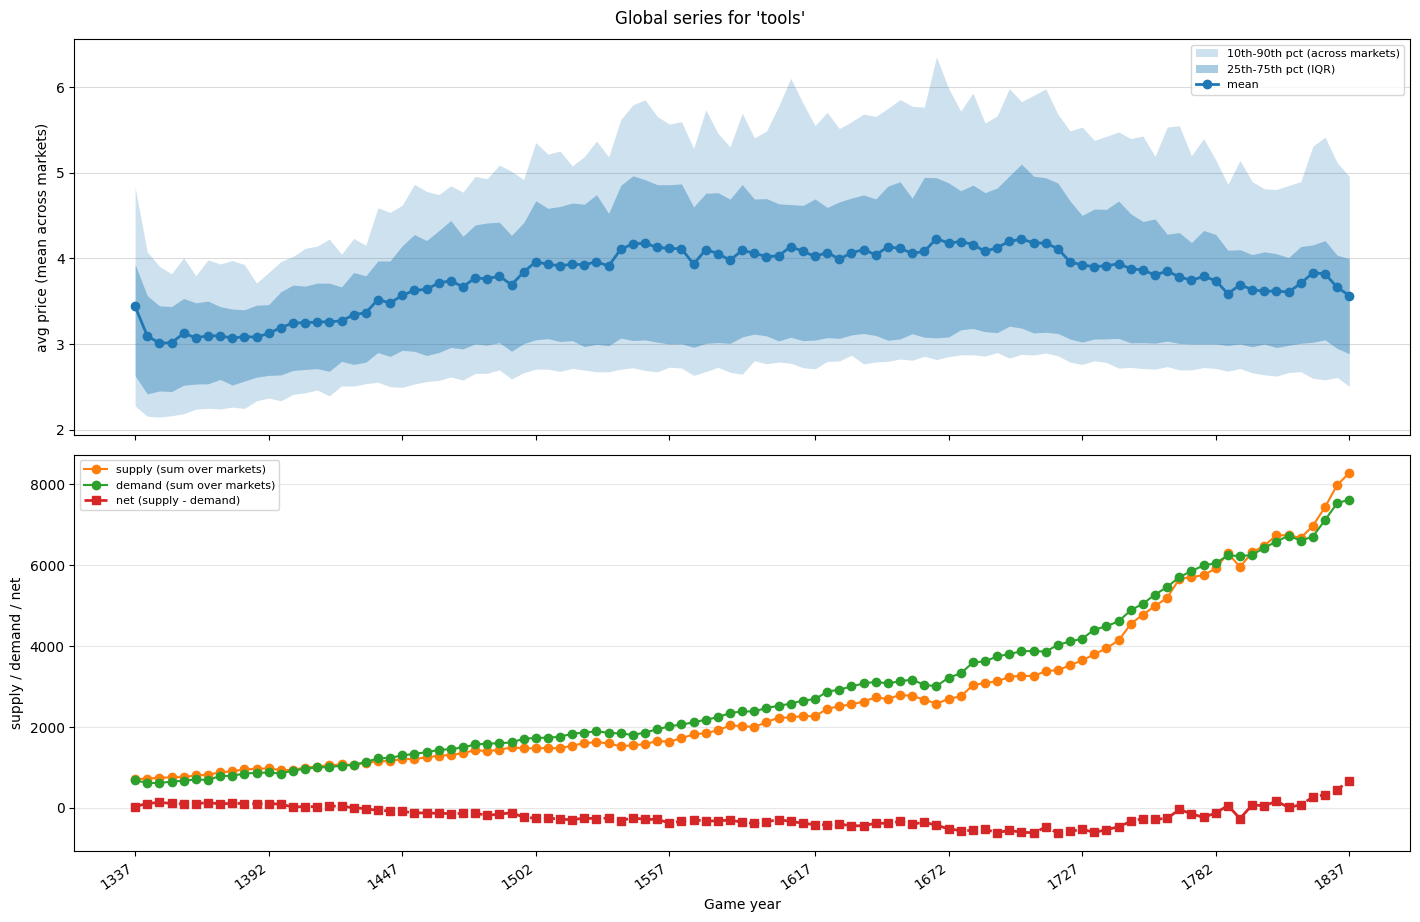

In [148]:
# Type your trade good here (EU5 good_id string)
GOOD_ID = "tools"

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.ticker import MultipleLocator


def _rows_for_good(df: pd.DataFrame, q: str) -> tuple[pd.DataFrame, str | None]:
    if df.empty or "good_id" not in df.columns:
        return pd.DataFrame(), None
    q = str(q).strip()
    m = df["good_id"].astype(str).str.lower() == q.lower()
    sub = df.loc[m].copy()
    if sub.empty:
        return pd.DataFrame(), None
    return sub, str(sub["good_id"].iloc[0])


sub, resolved = _rows_for_good(market_all, GOOD_ID)
if sub.empty:
    sample = sorted(market_all["good_id"].dropna().unique().tolist())[:40]
    print(f"No rows for good matching {GOOD_ID!r}. Sample good_id values: {sample}")
else:
    print(f"Using good_id={resolved!r} ({len(sub)} market rows across snapshots)")
    agg_parts = {}
    if "price" in sub.columns:
        agg_parts["avg_price"] = ("price", "mean")
    if "supply" in sub.columns:
        agg_parts["global_supply"] = ("supply", "sum")
    if "demand" in sub.columns:
        agg_parts["global_demand"] = ("demand", "sum")
    agg_parts["n_markets"] = ("market_id", "nunique")

    global_good = sub.groupby("snapshot", as_index=False).agg(**agg_parts)
    global_good = global_good.sort_values("snapshot").reset_index(drop=True)
    if "global_supply" in global_good.columns and "global_demand" in global_good.columns:
        global_good["net_supply_minus_demand"] = (
            global_good["global_supply"] - global_good["global_demand"]
        )

    print("Global aggregates per snapshot (mean price, summed supply/demand):")
    display(global_good)

    # Per-snapshot price spread across markets (ribbons on avg_price panel)
    price_band = None
    if "price" in sub.columns:
        _snaps = global_good["snapshot"].tolist()
        price_band = (
            sub.groupby("snapshot")["price"]
            .agg(
                p10=lambda s: s.quantile(0.1),
                p25=lambda s: s.quantile(0.25),
                p75=lambda s: s.quantile(0.75),
                p90=lambda s: s.quantile(0.9),
            )
            .reindex(_snaps)
        )

    # Line charts: price panel; supply+demand+net on one panel when both exist
    panels: list[str] = []
    if "avg_price" in global_good.columns:
        panels.append("price")
    if "global_supply" in global_good.columns and "global_demand" in global_good.columns:
        panels.append("supply_demand_net")
    else:
        if "global_supply" in global_good.columns:
            panels.append("supply")
        if "global_demand" in global_good.columns:
            panels.append("demand")

    if not panels:
        print("No plottable columns (need price and/or supply/demand).")
    else:
        n = len(panels)
        fig, axes = plt.subplots(n, 1, figsize=(13 * 1.1, 3.12 * 1.5 * n), sharex=True)
        if n == 1:
            axes = [axes]
        x = np.arange(len(global_good))
        for ax, panel in zip(axes, panels):
            if panel == "price":
                color = "C0"
                if price_band is not None:
                    ax.fill_between(
                        x,
                        price_band["p10"],
                        price_band["p90"],
                        alpha=0.22,
                        color=color,
                        linewidth=0,
                        label="10th-90th pct (across markets)",
                    )
                    ax.fill_between(
                        x,
                        price_band["p25"],
                        price_band["p75"],
                        alpha=0.38,
                        color=color,
                        linewidth=0,
                        label="25th-75th pct (IQR)",
                    )
                    ax.plot(
                        x,
                        global_good["avg_price"],
                        marker="o",
                        color=color,
                        linewidth=2,
                        zorder=3,
                        label="mean",
                    )
                    ax.legend(loc="best", fontsize=8)
                else:
                    ax.plot(x, global_good["avg_price"], marker="o", color=color)
                ax.set_ylabel("avg price (mean across markets)")
                ax.set_axisbelow(True)
                ax.yaxis.set_major_locator(MultipleLocator(1))
                ax.grid(True, axis="y", which="major", alpha=0.45, linestyle="-", linewidth=0.8, zorder=0)
            elif panel == "supply_demand_net":
                ax.plot(
                    x,
                    global_good["global_supply"],
                    marker="o",
                    color="C1",
                    label="supply (sum over markets)",
                )
                ax.plot(
                    x,
                    global_good["global_demand"],
                    marker="o",
                    color="C2",
                    label="demand (sum over markets)",
                )
                ax.plot(
                    x,
                    global_good["net_supply_minus_demand"],
                    marker="s",
                    color="C3",
                    linestyle="--",
                    linewidth=2,
                    label="net (supply - demand)",
                )
                ax.legend(loc="best", fontsize=8)
                ax.set_ylabel("supply / demand / net")
                ax.grid(True, axis="y", alpha=0.3)
            elif panel == "supply":
                ax.plot(x, global_good["global_supply"], marker="o", color="C1")
                ax.set_ylabel("global supply (sum)")
                ax.grid(True, axis="y", alpha=0.3)
            elif panel == "demand":
                ax.plot(x, global_good["global_demand"], marker="o", color="C2")
                ax.set_ylabel("global demand (sum)")
                ax.grid(True, axis="y", alpha=0.3)
        # Same time axis as compare_savegames.ipynb: first snapshot = start_year, +5y per pkl
        years_per_snapshot = 5
        start_year = 1337  # EU5 start
        n_game_ticks = 10  # match compare_savegames (~one label every ~50y when many pkls)
        n_pts = len(x)
        if n_pts <= 1:
            tick_positions = list(range(n_pts))
        elif n_pts <= n_game_ticks:
            tick_positions = list(range(n_pts))
        else:
            step = (n_pts - 1) / (n_game_ticks - 1)
            tick_positions = [int(round(i * step)) for i in range(n_game_ticks)]
        tick_labels = [start_year + pos * years_per_snapshot for pos in tick_positions]
        axes[-1].set_xticks(tick_positions)
        axes[-1].set_xticklabels(tick_labels, rotation=35, ha="right")
        axes[-1].set_xlabel("Game year")
        fig.suptitle(f"Global series for {resolved!r}")
        plt.tight_layout()
        plt.show()

### All goods: net global imbalance (%, 25-year buckets)

Each cell is **100 × net / (Σsupply + Σdemand)** for that good × **25-year bucket** across all markets. **Supply and demand are summed** over consecutive snapshots that cover **25 game years** (default: **5** snapshots × **5** years each); then **net = Σsupply − Σdemand** on that combined flow (empty when there is no flow).

**Colors** use **one scale for the whole table**, fixed to **−50 … +50** on the net % (so the midrange isn’t washed out); values **outside** that range still appear in the cells, but read as saturated at the same red/green.

Columns are **`start_year + 0, 25, 50, …`** (bucket starts). Tune **`bucket_years`** and **`years_per_snapshot`** in the next cell if your cadence differs.

In [145]:
import numpy as np
from IPython.display import display

# Timeline: first snapshot = start_year, +years_per_snapshot game years per pkl.
# Buckets: sum supply/demand over snapshots_per_bucket snapshots, then net % on that combined flow.
start_year = 1337  # EU5 start (same as compare_savegames)
years_per_snapshot = 5
bucket_years = 20
snapshots_per_bucket = max(1, bucket_years // years_per_snapshot)
# Color scale for heatmap (symmetric); values still shown numerically beyond this range
heatmap_vmax = 50

if market_all.empty or not {"good_id", "supply", "demand"}.issubset(market_all.columns):
    print("Need market_all with good_id, supply, demand.")
else:
    agg = market_all.groupby(["good_id", "snapshot"], as_index=False).agg(
        global_supply=("supply", "sum"),
        global_demand=("demand", "sum"),
    )
    snap_order = sorted(agg["snapshot"].unique(), key=lambda x: str(x))
    snap_to_idx = {s: i for i, s in enumerate(snap_order)}
    agg["snap_idx"] = agg["snapshot"].map(snap_to_idx)
    agg["bucket"] = agg["snap_idx"] // snapshots_per_bucket

    bucketed = agg.groupby(["good_id", "bucket"], as_index=False).agg(
        global_supply=("global_supply", "sum"),
        global_demand=("global_demand", "sum"),
    )
    bucketed["net"] = bucketed["global_supply"] - bucketed["global_demand"]
    denom = bucketed["global_supply"] + bucketed["global_demand"]
    bucketed["net_pct_flow"] = np.where(denom > 0, 100.0 * bucketed["net"] / denom, np.nan)

    net_wide = bucketed.pivot(index="good_id", columns="bucket", values="net_pct_flow")
    net_wide = net_wide.sort_index()
    net_wide = net_wide.reindex(sorted(net_wide.columns), axis=1)
    net_wide.columns = [str(start_year + int(b) * bucket_years) for b in net_wide.columns]

    styled = (
        net_wide.style.format("{:.1f}", na_rep="")
        .background_gradient(
            cmap="RdYlGn", axis=None, vmin=-heatmap_vmax, vmax=heatmap_vmax
        )
        .set_caption(
            f"{bucket_years}y buckets: 100×net/(S+D); colors [-{heatmap_vmax}, +{heatmap_vmax}] (same scale all cells); numbers uncapped"
        )
    )
    display(styled)

,1337,1357,1377,1397,1417,1437,1457,1477,1497,1517,1537,1557,1577,1597,1617,1637,1657,1677,1697,1717,1737,1757,1777,1797,1817,1837
good_id,,,,,,,,,,,,,,,,,,,,,,,,,,
alum,52.2,46.6,42.5,40.8,40.4,34.7,31.0,33.1,28.2,29.4,28.3,23.7,23.5,18.8,17.7,21.0,19.6,17.4,16.5,12.1,6.9,8.3,5.5,6.3,6.0,6.4
amber,35.3,36.5,30.0,28.1,24.7,21.2,19.9,22.3,16.6,16.0,12.7,15.3,3.1,-2.7,-9.9,-30.6,-32.1,-36.5,-33.8,-31.4,-28.1,-29.1,-24.3,-24.8,-23.0,-27.4
beer,12.9,12.3,8.9,4.2,1.6,-0.8,-5.6,-4.9,-7.1,-5.1,-7.4,-9.7,-8.4,-6.5,-7.0,-6.4,-9.2,-5.7,-8.6,-5.0,-3.1,-0.4,2.6,2.8,3.5,3.5
beeswax,8.6,14.3,17.3,14.4,12.4,10.0,6.0,7.3,3.6,3.1,1.6,3.0,0.7,1.9,2.3,1.8,-0.4,2.2,-1.5,2.4,2.1,1.8,6.4,6.7,6.8,8.2
books,19.1,9.9,4.6,3.4,0.1,-6.2,-6.8,-6.8,-10.6,-6.2,-1.8,4.6,6.8,8.4,8.3,9.6,11.6,12.9,11.6,15.8,18.3,22.4,26.4,26.0,28.2,35.9
cannons,-100.0,-100.0,-99.0,-3.7,26.0,-30.0,15.5,22.8,10.8,14.4,6.9,13.0,-13.5,3.0,0.6,5.5,5.6,2.3,4.3,-1.5,4.2,4.0,-0.9,6.1,9.2,11.8
chili,45.2,49.7,59.6,47.0,47.7,47.5,43.2,47.8,51.4,48.0,49.9,43.0,51.2,56.7,56.3,56.3,58.8,74.2,68.9,72.3,63.9,-8.2,-24.8,-22.6,-18.3,-18.0
clay,17.4,20.9,14.5,8.3,4.5,1.9,-2.3,-1.9,-3.2,-2.5,-2.2,-1.3,-0.5,0.2,-0.1,-0.5,1.2,1.0,0.3,0.7,1.2,2.0,3.3,4.2,4.1,4.7
cloth,21.9,21.3,20.2,17.8,15.9,9.4,7.9,6.5,3.0,2.4,2.4,-1.1,0.6,-1.1,-2.5,-1.3,-2.0,-2.2,-2.0,-1.1,-1.0,5.3,4.7,5.5,6.4,5.5


In [146]:
# Countries table per snapshot (tags from save)
cparts = []
for label, cdf in countries_by_label.items():
    if cdf is None or cdf.empty:
        continue
    t = cdf.copy()
    t["snapshot"] = label
    cparts.append(t)
countries_all = pd.concat(cparts, ignore_index=True) if cparts else pd.DataFrame()
if not countries_all.empty:
    display(countries_all.head(20))
else:
    print("No countries dataframe in payload.")

,country_id,country_tag,name,population,gold,stability,prestige,monthly_income,government_type,snapshot
0,0,DUMMY,DUMMY,0.0,0.00000,0.0,0.0,0.00000,,20260320_213623
1,1,PIR,PIR,0.0,0.00000,0.0,0.0,0.00000,,20260320_213623
2,2,MER,MER,0.0,0.00000,0.0,0.0,10.91929,,20260320_213623
3,3,SWE,SWE,0.0,26.58468,0.0,0.0,26.58468,monarchy,20260320_213623
4,4,DAN,DAN,0.0,7.41507,0.0,0.0,7.41507,monarchy,20260320_213623
5,5,SKE,SKE,0.0,3.49481,0.0,0.0,3.49481,monarchy,20260320_213623
6,6,NOR,NOR,0.0,16.58698,0.0,0.0,16.58698,monarchy,20260320_213623
7,7,FIN,FIN,0.0,0.00000,0.0,0.0,0.00000,monarchy,20260320_213623
8,8,BJA,BJA,0.0,0.00000,0.0,0.0,0.00000,tribe,20260320_213623
9,9,TAV,TAV,0.0,0.00000,0.0,0.0,0.00000,tribe,20260320_213623
